<a href="https://colab.research.google.com/github/EEHZYDHAVE/behavioural-credit-signals-for-fintech/blob/Section-one/Expanding_Access_to_Credit_Invisible_Segment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Expanding Access to "Credit Invisible" Segments**
# **Part 1, Do Demographic Proxies Predict NPL Outcomes for Credit-Invisible Borrowers?**

---

#### What This Notebook Is About

Traditional lenders assess borrowers using demographic proxies, age, education level, employment type, marital status. For most borrowers, this works alongside credit history. But for **credit-invisible borrowers**, people who have never taken a loan and therefore have no credit record anywhere, demographic proxies are often the *only* tool lenders have.

The question this notebook investigates is simple: **how good is that tool, really?**

Before we can argue that a better approach exists, we need to honestly measure the current one. This notebook does exactly that, it isolates true credit-invisible borrowers, tests each demographic proxy against actual loan default outcomes, and produces a measurable baseline that tells us how much signal the traditional approach actually carries.

<br>

#### Dataset
Source: Home Credit Default Risk, Kaggle

The primary file is `application_train.csv`, which contains borrower demographics, loan details, and a binary target variable indicating whether the borrower defaulted. `bureau.csv` and `previous_application.csv` are used exclusively as filters to isolate borrowers with no prior credit history.



#### Tools
- **Google Colab**, Development environment
- **Python**, Pandas, NumPy, Matplotlib, Seaborn, SciPy



#### How This Notebook Is Structured
| Stage | Description |
|---|---|
| Stage 1 | Isolate the credit-invisible population |
| Stage 2 | Population audit |
| Stage 3 | Variable classification and exclusions |
| Stage 4 | Exploratory data analysis |
| Stage 5 | Univariate signal evaluation |
| Stage 6 | Subgroup profiling |
| Stage 7 | Baseline verdict |



> **Note:** This is Part 1 of a two-part project. The findings here establish the baseline. Part 2 will test whether behavioral signals from payment history can outperform these demographic proxies for the same population.

## **1 Importing the Necessary Librabry**

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
# Download the dataset

dataset_url = 'https://www.kaggle.com/competitions/home-credit-default-risk/data'

%time
od.download(dataset_url)

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 6.68 µs
Skipping, found downloaded files in "./home-credit-default-risk" (use force=True to force download)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

### **1.1 Viewing the Dataset**

In [ ]:
data_dir = 'home-credit-default-risk'
!ls -lh {data_dir}

total 2.5G
-rw-r--r-- 1 root root  26M Feb 28 12:09 application_test.csv
-rw-r--r-- 1 root root 159M Feb 28 12:09 application_train.csv
-rw-r--r-- 1 root root 359M Feb 28 12:09 bureau_balance.csv
-rw-r--r-- 1 root root 163M Feb 28 12:09 bureau.csv
-rw-r--r-- 1 root root 405M Feb 28 12:09 credit_card_balance.csv
-rw-r--r-- 1 root root  37K Feb 28 12:09 HomeCredit_columns_description.csv
-rw-r--r-- 1 root root 690M Feb 28 12:09 installments_payments.csv
-rw-r--r-- 1 root root 375M Feb 28 12:09 POS_CASH_balance.csv
-rw-r--r-- 1 root root 387M Feb 28 12:09 previous_application.csv
-rw-r--r-- 1 root root 524K Feb 28 12:09 sample_submission.csv


## **2 Data Cleaning**


### **2.1 Data Investigation & Cleaning**

Before attempting to clean the dataset, we are investigating the dataset because the cleaning here can be tricky because of the kind of information captured in the data. For instance in the ```age``` column, we expect a negative value, so the cleaning would be to convert to age (```-12775``` becomes ```35```)

In [ ]:
# Load the three files
app = pd.read_csv(f'{data_dir}/application_train.csv')
bureau = pd.read_csv(f'{data_dir}/bureau.csv')
prev = pd.read_csv(f'{data_dir}/previous_application.csv')

# Function to print a clean diagnostic report for any dataframe
def diagnose(df, name):
    print(f"\n{'='*60}")
    print(f"DIAGNOSTIC REPORT: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

    # Duplicate check
    dupes = df.duplicated().sum()
    print(f"Duplicate rows: {dupes}")

    # Missing values - only show columns that have any
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    }).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

    if missing_df.empty:
        print("Missing values: None")
    else:
        print(f"\nColumns with missing values ({len(missing_df)} of {df.shape[1]}):")
        print(missing_df.to_string())

    # Data types
    print(f"\nData Types:")
    print(df.dtypes.value_counts().to_string())

# Run diagnostics
diagnose(app, 'application_train.csv')
diagnose(bureau, 'bureau.csv')
diagnose(prev, 'previous_application.csv')


DIAGNOSTIC REPORT: application_train.csv
Shape: 307,511 rows x 122 columns
Duplicate rows: 0

Columns with missing values (67 of 122):
                              Missing Count  Missing %
COMMONAREA_MEDI                      214865      69.87
COMMONAREA_MODE                      214865      69.87
COMMONAREA_AVG                       214865      69.87
NONLIVINGAPARTMENTS_MODE             213514      69.43
NONLIVINGAPARTMENTS_MEDI             213514      69.43
NONLIVINGAPARTMENTS_AVG              213514      69.43
FONDKAPREMONT_MODE                   210295      68.39
LIVINGAPARTMENTS_AVG                 210199      68.35
LIVINGAPARTMENTS_MEDI                210199      68.35
LIVINGAPARTMENTS_MODE                210199      68.35
FLOORSMIN_MEDI                       208642      67.85
FLOORSMIN_MODE                       208642      67.85
FLOORSMIN_AVG                        208642      67.85
YEARS_BUILD_MODE                     204488      66.50
YEARS_BUILD_MEDI                     20

#### Data Cleaning Decisions
Based on the diagnostic report, here is what we found and what we are doing about it:
<br>
```Application_train.csv``` has 67 columns with missing values but most of them are building and property features ```(COMMONAREA, APARTMENTS, ELEVATORS etc.)``` which are not demographic proxies and are out of scope for this analysis. We drop these entirely. <br><br>
```EXT_SOURCE_1```, ```EXT_SOURCE_2```, and ```EXT_SOURCE_3``` are external credit score proxies, not traditional demographic variables, so we exclude them regardless of missingness. The one demographic column with significant missingness is ```OCCUPATION_TYPE``` at ```31%```. <br><br>
Rather than dropping it or guessing the values, we fill missing entries with ```"Unknown"``` because in the real world a borrower not disclosing their occupation is itself informative and may carry signal. ```DAYS_BIRTH``` is stored as negative days and will be converted to age in years.<br><br>
```bureau.csv``` and ```previous_application.csv``` are only used to extract ```SK_ID_CURR``` for the credit-invisible filter. That column is complete in both files so no cleaning is needed.

In [ ]:
# ============================================================
# DATA CLEANING
# ============================================================

# --- application_train.csv ---

# 1. Convert DAYS_BIRTH from negative days to age in years
app['AGE'] = (app['DAYS_BIRTH'].abs() / 365).astype(int)

# 2. Convert DAYS_EMPLOYED to positive — negative means currently employed
#    365243 is a placeholder value used for pensioners/unemployed, replace with 0
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, 0)
app['EMPLOYMENT_YEARS'] = (app['DAYS_EMPLOYED'].abs() / 365).round(1)

# 3. Fill OCCUPATION_TYPE missing values with 'Unknown'
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# 4. Drop building/property features — not demographic proxies, out of scope
property_cols = [col for col in app.columns if any(x in col for x in [
    'APARTMENTS', 'BASEMENTAREA', 'YEARS_BUILD', 'COMMONAREA',
    'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN', 'LANDAREA',
    'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS', 'NONLIVINGAREA',
    'TOTALAREA', 'WALLSMATERIAL', 'EMERGENCYSTATE', 'FONDKAPREMONT',
    'HOUSETYPE', 'YEARS_BEGINEXPLUATATION'
])]
app = app.drop(columns=property_cols)

# 5. Drop EXT_SOURCE columns — external credit score proxies, not demographics
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
app = app.drop(columns=ext_cols, errors='ignore')

# 6. Drop AMT_REQ_CREDIT_BUREAU columns — these reference bureau activity
bureau_req_cols = [col for col in app.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
app = app.drop(columns=bureau_req_cols)

# Confirm result
print(f"application_train shape after cleaning: {app.shape}")
print(f"Remaining columns: {app.shape[1]}")
print(f"\nRemaining missing values:")
remaining_missing = app.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing if not remaining_missing.empty else "None")

application_train shape after cleaning: (307511, 68)
Remaining columns: 68

Remaining missing values:
AMT_ANNUITY                     12
AMT_GOODS_PRICE                278
NAME_TYPE_SUITE               1292
OWN_CAR_AGE                 202929
CNT_FAM_MEMBERS                  2
OBS_30_CNT_SOCIAL_CIRCLE      1021
DEF_30_CNT_SOCIAL_CIRCLE      1021
OBS_60_CNT_SOCIAL_CIRCLE      1021
DEF_60_CNT_SOCIAL_CIRCLE      1021
DAYS_LAST_PHONE_CHANGE           1
dtype: int64


Removing other columns not relevant to the study and cleaning the core columns needed

In [ ]:
# ============================================================
# SELECT CORE COLUMNS ONLY
# ============================================================

core_columns = [
    # Identifier and outcome
    'SK_ID_CURR', 'TARGET',

    # Pure demographics
    'AGE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',

    # Loan request characteristics
    'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',

    # Soft stability signals
    'EMPLOYMENT_YEARS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE',
    'REGION_RATING_CLIENT', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]

# Keep only core columns
app = app[core_columns]

# Check shape and missing values
print(f"Dataset shape after column selection: {app.shape}")
print(f"\nMissing values per column:")
missing = app.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "No missing values")

# Quick overview of the dataset
print(f"\nData types:")
print(app.dtypes)

Dataset shape after column selection: (307511, 26)

Missing values per column:
CNT_FAM_MEMBERS      2
AMT_ANNUITY         12
AMT_GOODS_PRICE    278
dtype: int64

Data types:
SK_ID_CURR                   int64
TARGET                       int64
AGE                          int64
CODE_GENDER                 object
NAME_EDUCATION_TYPE         object
NAME_FAMILY_STATUS          object
CNT_CHILDREN                 int64
CNT_FAM_MEMBERS            float64
NAME_INCOME_TYPE            object
AMT_INCOME_TOTAL           float64
OCCUPATION_TYPE             object
ORGANIZATION_TYPE           object
NAME_CONTRACT_TYPE          object
AMT_CREDIT                 float64
AMT_ANNUITY                float64
AMT_GOODS_PRICE            float64
EMPLOYMENT_YEARS           float64
FLAG_OWN_CAR                object
FLAG_OWN_REALTY             object
NAME_HOUSING_TYPE           object
REGION_RATING_CLIENT         int64
DAYS_REGISTRATION          float64
DAYS_ID_PUBLISH              int64
REG_CITY_NOT_LIVE_CIT

In [ ]:
# Fix the 3 remaining missing values
app['CNT_FAM_MEMBERS'] = app['CNT_FAM_MEMBERS'].fillna(app['CNT_FAM_MEMBERS'].median())
app['AMT_ANNUITY'] = app['AMT_ANNUITY'].fillna(app['AMT_ANNUITY'].median())
app['AMT_GOODS_PRICE'] = app['AMT_GOODS_PRICE'].fillna(app['AMT_GOODS_PRICE'].median())

# Final confirmation
print(f"Missing values remaining: {app.isnull().sum().sum()}")
print(f"Dataset ready: {app.shape}")

Missing values remaining: 0
Dataset ready: (307511, 26)


### 2.2 Isolating the Credit-Invisible Population

The goal of this project is to evaluate how well traditional demographic proxies predict NPL outcomes
for credit-invisible borrowers, people who had no prior credit history at the time they applied for
a loan with Home Credit.

To study this group specifically, we need to remove anyone from our dataset who already had a credit
footprint. We do this by cross-checking our main dataset against two files:

- **`bureau.csv`** contains records of borrowers who had prior loans or credit with external
financial institutions. Any borrower appearing here had an external credit history.

- **`previous_application.csv`** contains records of borrowers who had previously applied for a
loan with Home Credit itself. Any borrower appearing here had an internal credit history.

Any `SK_ID_CURR` that appears in either of these two files is removed from our working dataset.
What remains are borrowers who were completely invisible to traditional credit systems at the point
of application, no external bureau record, no prior Home Credit relationship. This is our true
study population.

> **Why this matters:** Without this filter we would be studying all borrowers, and any finding
about demographic proxies would be diluted by borrowers whose creditworthiness was already partially
known through their credit history. This filter is what makes the analysis honest and the findings
specific to the credit-invisible segment.

In [ ]:
# ============================================================
# STAGE 2 — ISOLATING THE CREDIT-INVISIBLE POPULATION
# ============================================================

# Get all SK_ID_CURR values that appear in bureau or previous_application
bureau_ids = set(bureau['SK_ID_CURR'].unique())
prev_ids = set(prev['SK_ID_CURR'].unique())

# Combine into one set of credit-visible IDs
credit_visible_ids = bureau_ids.union(prev_ids)

# Filter app to keep only borrowers NOT in either file
credit_invisible = app[~app['SK_ID_CURR'].isin(credit_visible_ids)].copy()

# ============================================================
# POPULATION AUDIT
# ============================================================

total_borrowers = len(app)
invisible_borrowers = len(credit_invisible)
visible_borrowers = total_borrowers - invisible_borrowers

print(f"Total borrowers in dataset:        {total_borrowers:,}")
print(f"Credit-visible borrowers removed:  {visible_borrowers:,}")
print(f"Credit-invisible borrowers kept:   {invisible_borrowers:,}")
print(f"Credit-invisible as % of total:    {invisible_borrowers/total_borrowers*100:.1f}%")

print(f"\n--- NPL Rate Comparison ---")
print(f"NPL rate (full dataset):           {app['TARGET'].mean()*100:.2f}%")
print(f"NPL rate (credit-invisible only):  {credit_invisible['TARGET'].mean()*100:.2f}%")

print(f"\n--- Class Distribution (Credit-Invisible) ---")
print(credit_invisible['TARGET'].value_counts())
print(f"\nClass balance ratio: {credit_invisible['TARGET'].value_counts()[0] / credit_invisible['TARGET'].value_counts()[1]:.1f}:1")

Total borrowers in dataset:        307,511
Credit-visible borrowers removed:  305,041
Credit-invisible borrowers kept:   2,470
Credit-invisible as % of total:    0.8%

--- NPL Rate Comparison ---
NPL rate (full dataset):           8.07%
NPL rate (credit-invisible only):  7.29%

--- Class Distribution (Credit-Invisible) ---
TARGET
0    2290
1     180
Name: count, dtype: int64

Class balance ratio: 12.7:1


### **2.3 Population Definition & Revised Framing**

#### What We Did and What We Found

As an initial step, we cross-checked `application_train.csv` against `bureau.csv` and
`previous_application.csv` to identify borrowers with absolutely no prior credit history
of any kind. The results were as follows:

- Out of **307,511** total borrowers, only **2,470 (0.8%)** had no external bureau record
and no previous Home Credit relationship.
- The NPL rate for this strictly filtered group was **7.29%**, slightly lower than the
full dataset NPL rate of **8.07%**.
- Within this group, only **180 borrowers** actually defaulted, a very thin foundation
for demographic analysis.

#### The Methodological Problem This Revealed

This exercise exposed a logical tension in our original framing. A **purely credit-invisible
borrower**, someone with zero credit history anywhere, cannot have an NPL outcome by
definition, because NPL requires a loan to have existed first. The 2,470 borrowers we
isolated represent people whose **first ever loan** was with Home Credit, which is why
their numbers are so small and their default cases so few.

Trying to predict NPL outcomes for purely credit-invisible borrowers is therefore a
logical contradiction. You cannot measure the performance of a screening tool on people
who were never screened before.

#### The Correct Population Definition

However, the dataset description from Home Credit resolves this tension directly:

> *"Many people struggle to get loans due to insufficient or non-existent credit histories.
> Home Credit strives to broaden financial inclusion for the unbanked population by providing
> a positive and safe borrowing experience."*

Home Credit's entire business model is serving the **underserved and underbanked population**,
people with insufficient or non-existent credit histories. This means the full dataset is
already the right population for our research question. Every borrower here is some version
of credit-invisible or thin-file by the dataset's own design.

The correct term for our study population is therefore **thin-file borrowers**, a subset
of the broader credit-invisible class who have limited rather than zero credit history.
This is the population traditional lenders underserve, and it is the population where
the question of whether demographic proxies are sufficient becomes most relevant.

#### Revised Project Framing

| | Original | Revised |
|---|---|---|
| **Population** | Pure credit-invisible borrowers | Thin-file / underbanked borrowers |
| **Dataset** | Filtered subset (2,470) | Full dataset (307,511) |
| **Research question** | Can demographics predict NPL for people with no credit history? | How well do traditional demographic proxies predict NPL for underserved borrowers with limited credit history? |

#### Why This Does Not Change the Story

This reframing does not weaken the project, it strengthens it. The core argument remains
intact:

1. Traditional lenders use demographic proxies to assess borrowers with limited credit history
2. We measure how well those proxies actually predict NPL outcomes
3. We then test whether behavioral signals predict NPL outcomes better
4. If they do, we have evidence that alternative data can expand credit access without
expanding risk

The only thing that changed is we are now working with a statistically robust sample of
**307,511 borrowers** rather than a thin subset of 2,470, which makes our findings
more reliable and more generalizable.

In [ ]:
# ============================================================
# RELOAD & CLEAN — FULL WORKING DATASET
# ============================================================

# Load fresh
app = pd.read_csv(f'{data_dir}/application_train.csv')

# 1. Convert DAYS_BIRTH to AGE in years
app['AGE'] = (app['DAYS_BIRTH'].abs() / 365).astype(int)

# 2. Clean DAYS_EMPLOYED and convert to years
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, 0)
app['EMPLOYMENT_YEARS'] = (app['DAYS_EMPLOYED'].abs() / 365).round(1)

# 3. Fill OCCUPATION_TYPE missing with Unknown
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# 4. Select only our defined feature set
cols_to_keep = [
    'SK_ID_CURR', 'TARGET',
    # Pure demographics
    'AGE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE',
    'AMT_INCOME_TOTAL', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    # Loan request characteristics
    'NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    # Soft stability signals
    'EMPLOYMENT_YEARS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE', 'REGION_RATING_CLIENT', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]
app = app[cols_to_keep].copy()

# 5. Handle remaining missing values
app['CNT_FAM_MEMBERS'] = app['CNT_FAM_MEMBERS'].fillna(app['CNT_FAM_MEMBERS'].median())
app['AMT_ANNUITY'] = app['AMT_ANNUITY'].fillna(app['AMT_ANNUITY'].median())
app['AMT_GOODS_PRICE'] = app['AMT_GOODS_PRICE'].fillna(app['AMT_GOODS_PRICE'].median())

# Confirm
print(f"Dataset shape: {app.shape}")
print(f"Missing values: {app.isnull().sum().sum()}")
print(f"NPL rate: {app['TARGET'].mean()*100:.2f}%")
print(f"\nClass distribution:")
print(app['TARGET'].value_counts())

Dataset shape: (307511, 26)
Missing values: 0
NPL rate: 8.07%

Class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


## **3 Exploratory Data Analysis**

Now that the dataset is clean and our population is confirmed, we take a step back and
just look at who these borrowers are before asking any analytical questions.

This stage covers three things:
- The overall population profile, age, gender, education, income, employment
- How the NPL rate varies across key demographic groups visually
- Any early patterns worth noting before formal analysis begins

No statistical testing happens here. No bucket separation yet. We are simply building
intuition about the population before we start measuring anything.

/tmp/ipython-input-211/1904755006.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  npl_by_age = app.groupby('AGE_GROUP')['TARGET'].mean() * 100


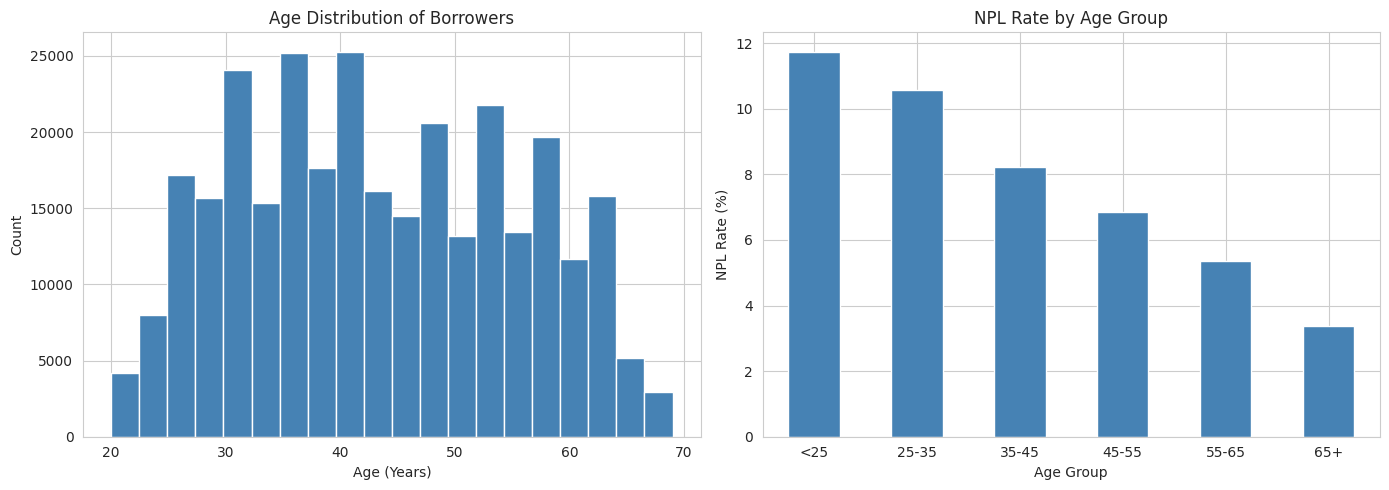

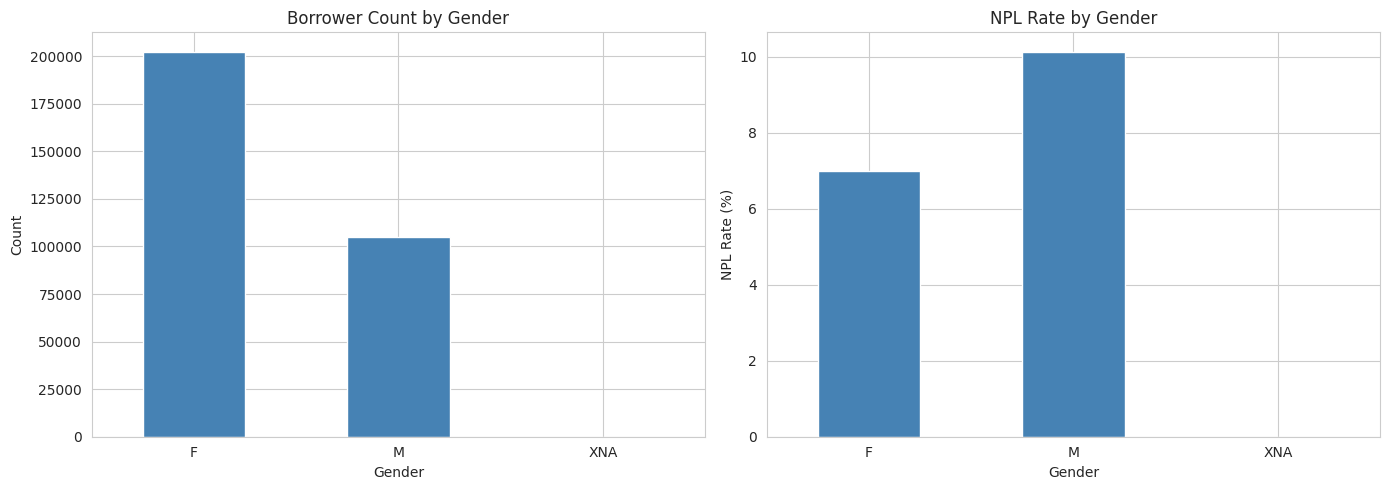

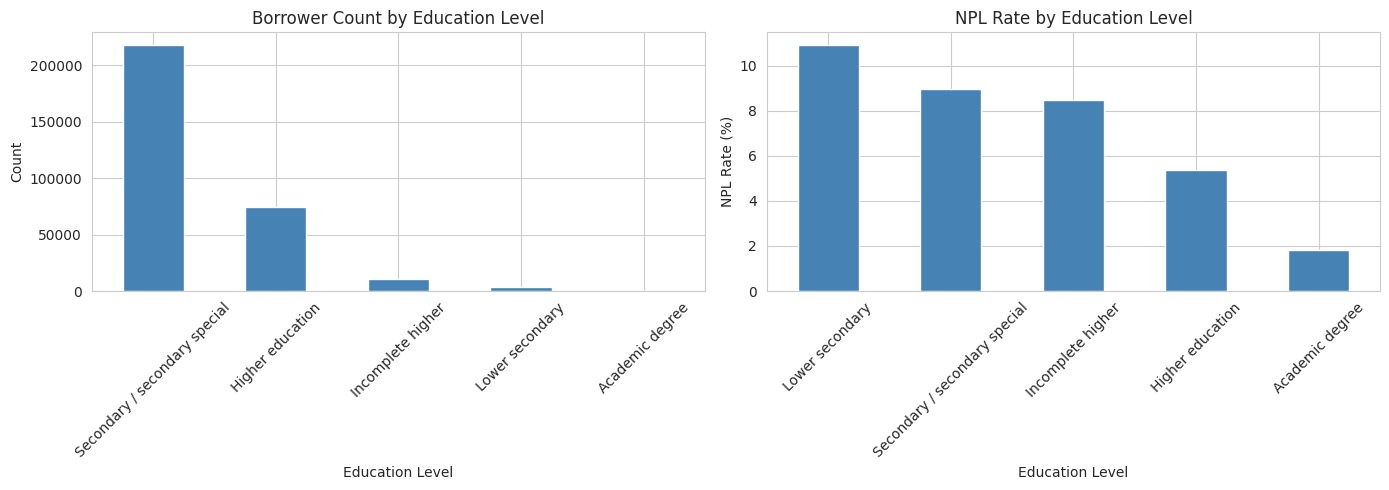

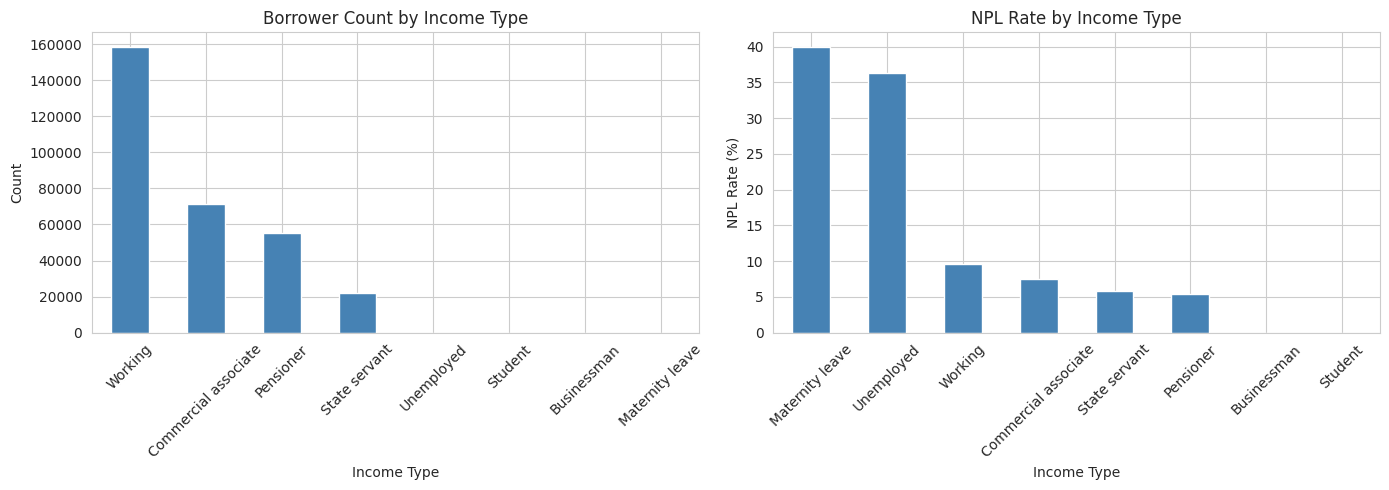

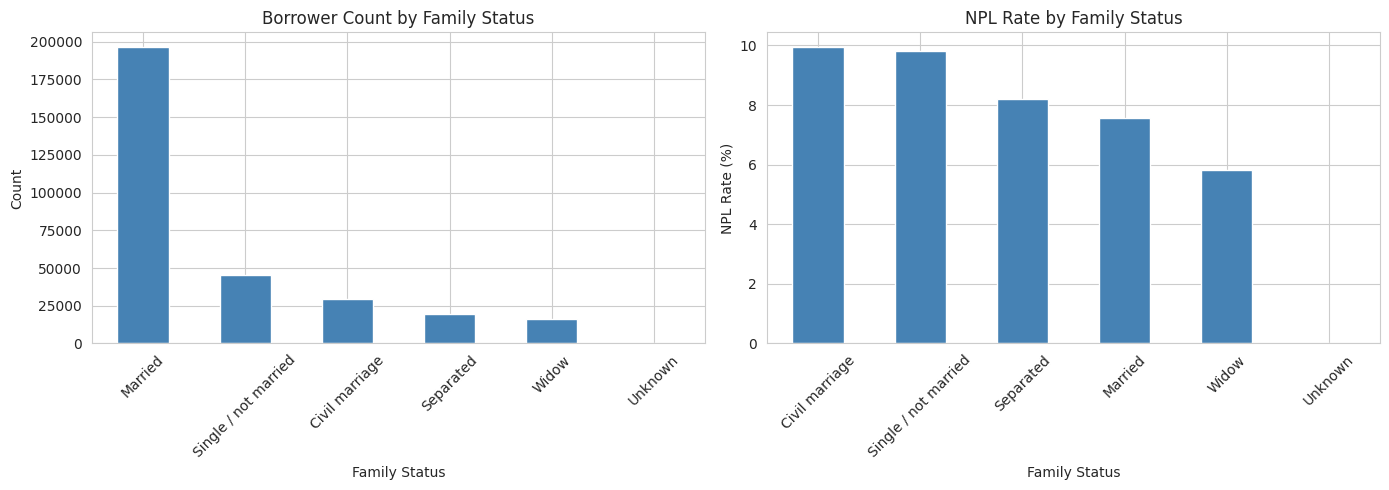

/tmp/ipython-input-211/1904755006.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  npl_by_income_bracket = app.groupby('INCOME_BRACKET')['TARGET'].mean() * 100


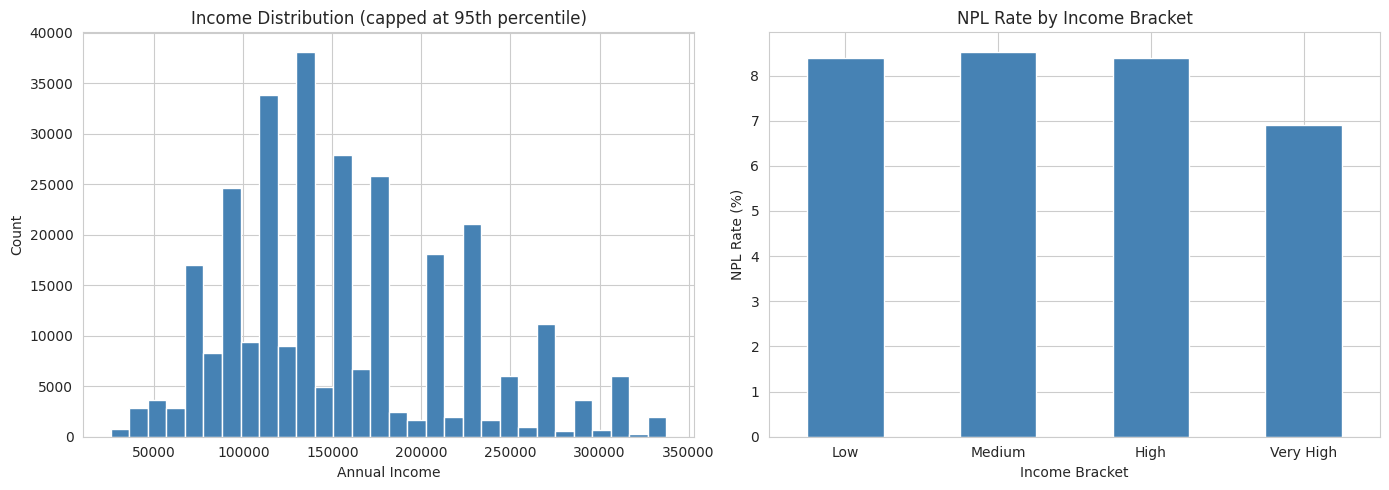

=== OVERALL NPL RATE ===
8.07%

=== NPL RATE BY KEY DEMOGRAPHICS ===

AGE_GROUP:
           Borrower Count  NPL Rate (%)
AGE_GROUP                              
<25                 16318         11.74
25-35               75925         10.59
35-45               83677          8.24
45-55               69501          6.85
55-65               57081          5.34
65+                  5009          3.37

CODE_GENDER:
             Borrower Count  NPL Rate (%)
CODE_GENDER                              
F                    202448          7.00
M                    105059         10.14
XNA                       4          0.00

NAME_EDUCATION_TYPE:
                               Borrower Count  NPL Rate (%)
NAME_EDUCATION_TYPE                                        
Academic degree                           164          1.83
Higher education                        74863          5.36
Incomplete higher                       10277          8.48
Lower secondary                          3816        

/tmp/ipython-input-211/1904755006.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = app.groupby(col)['TARGET'].agg(['mean','count'])


                      Borrower Count  NPL Rate (%)
NAME_FAMILY_STATUS                                
Civil marriage                 29775          9.94
Married                       196432          7.56
Separated                      19770          8.19
Single / not married           45444          9.81
Unknown                            2          0.00
Widow                          16088          5.82

INCOME_BRACKET:
                Borrower Count  NPL Rate (%)
INCOME_BRACKET                              
Low                     100578          8.39
Medium                   53182          8.53
High                     82213          8.40
Very High                71538          6.91


/tmp/ipython-input-211/1904755006.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = app.groupby(col)['TARGET'].agg(['mean','count'])


In [ ]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ============================================================
# 1. AGE DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(app['AGE'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution of Borrowers')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# NPL rate by age group
app['AGE_GROUP'] = pd.cut(app['AGE'], bins=[0,25,35,45,55,65,100],
                           labels=['<25','25-35','35-45','45-55','55-65','65+'])
npl_by_age = app.groupby('AGE_GROUP')['TARGET'].mean() * 100
npl_by_age.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# 2. GENDER
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app['CODE_GENDER'].value_counts().plot(kind='bar', ax=axes[0],
                                        color='steelblue', edgecolor='white')
axes[0].set_title('Borrower Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

npl_by_gender = app.groupby('CODE_GENDER')['TARGET'].mean() * 100
npl_by_gender.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# 3. EDUCATION LEVEL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app['NAME_EDUCATION_TYPE'].value_counts().plot(kind='bar', ax=axes[0],
                                                color='steelblue', edgecolor='white')
axes[0].set_title('Borrower Count by Education Level')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

npl_by_edu = app.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
npl_by_edu.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
                                              color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 4. INCOME TYPE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app['NAME_INCOME_TYPE'].value_counts().plot(kind='bar', ax=axes[0],
                                             color='steelblue', edgecolor='white')
axes[0].set_title('Borrower Count by Income Type')
axes[0].set_xlabel('Income Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

npl_by_income = app.groupby('NAME_INCOME_TYPE')['TARGET'].mean() * 100
npl_by_income.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
                                                 color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Income Type')
axes[1].set_xlabel('Income Type')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 5. FAMILY STATUS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

app['NAME_FAMILY_STATUS'].value_counts().plot(kind='bar', ax=axes[0],
                                               color='steelblue', edgecolor='white')
axes[0].set_title('Borrower Count by Family Status')
axes[0].set_xlabel('Family Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

npl_by_family = app.groupby('NAME_FAMILY_STATUS')['TARGET'].mean() * 100
npl_by_family.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
                                                 color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Family Status')
axes[1].set_xlabel('Family Status')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 6. INCOME DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap at 95th percentile to avoid extreme outliers distorting the chart
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.95)
app[app['AMT_INCOME_TOTAL'] <= income_cap]['AMT_INCOME_TOTAL'].hist(
    bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Income Distribution (capped at 95th percentile)')
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Count')

# NPL rate by income bracket
app['INCOME_BRACKET'] = pd.qcut(app['AMT_INCOME_TOTAL'], q=4,
                                  labels=['Low','Medium','High','Very High'])
npl_by_income_bracket = app.groupby('INCOME_BRACKET')['TARGET'].mean() * 100
npl_by_income_bracket.plot(kind='bar', ax=axes[1],
                            color='steelblue', edgecolor='white')
axes[1].set_title('NPL Rate by Income Bracket')
axes[1].set_xlabel('Income Bracket')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("=== OVERALL NPL RATE ===")
print(f"{app['TARGET'].mean()*100:.2f}%\n")

print("=== NPL RATE BY KEY DEMOGRAPHICS ===")
for col in ['AGE_GROUP', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
            'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'INCOME_BRACKET']:
    print(f"\n{col}:")
    summary = app.groupby(col)['TARGET'].agg(['mean','count'])
    summary['NPL Rate (%)'] = (summary['mean'] * 100).round(2)
    summary = summary.rename(columns={'count': 'Borrower Count'})
    print(summary[['Borrower Count', 'NPL Rate (%)']].to_string())

### **3.1 EDA Findings**

#### Overall NPL Rate
The overall NPL rate across all 307,511 borrowers is **8.07%**. This is our reference
point, any demographic group above this rate is higher risk than average, and any group
below it is lower risk than average.

---

#### Age
Age shows the clearest and most consistent pattern of any demographic variable examined.
NPL rate drops steadily as borrowers get older:

| Age Group | Borrower Count | NPL Rate |
|---|---|---|
| Under 25 | 16,318 | 11.74% |
| 25 — 35 | 75,925 | 10.59% |
| 35 — 45 | 83,677 | 8.24% |
| 45 — 55 | 69,501 | 6.85% |
| 55 — 65 | 57,081 | 5.34% |
| 65+ | 5,009 | 3.37% |

The relationship is clean and monotonic, every age group is lower risk than the one
before it. Younger borrowers are significantly more likely to default. This makes age
one of the stronger demographic signals in the dataset.

---

#### Gender
Male borrowers default at **10.14%** compared to **7.00%** for female borrowers, a gap
of over 3 percentage points against an overall rate of 8.07%. This is a meaningful
difference and suggests gender carries moderate predictive signal.

| Gender | Borrower Count | NPL Rate |
|---|---|---|
| Female | 202,448 | 7.00% |
| Male | 105,059 | 10.14% |

---

#### Education Level
Education shows a general pattern, lower education correlates with higher default rates, but the relationship is not perfectly clean.

| Education Level | Borrower Count | NPL Rate |
|---|---|---|
| Academic degree | 164 | 1.83% |
| Higher education | 74,863 | 5.36% |
| Incomplete higher | 10,277 | 8.48% |
| Secondary / secondary special | 218,391 | 8.94% |
| Lower secondary | 3,816 | 10.93% |

The most reliable comparison is **higher education (5.36%) vs secondary education
(8.94%)**, a real and meaningful gap based on large sample sizes. The academic degree
figure of 1.83% is interesting but based on only 164 borrowers and should be interpreted
with caution.

---

#### Income Type
Income type produces some extreme NPL rates but several categories have very small
sample sizes that make them statistically unreliable.

| Income Type | Borrower Count | NPL Rate |
|---|---|---|
| Working | 158,774 | 9.59% |
| Commercial associate | 71,617 | 7.48% |
| Pensioner | 55,362 | 5.39% |
| State servant | 21,703 | 5.75% |
| Unemployed | 22 | 36.36% |
| Maternity leave | 5 | 40.00% |

The meaningful signal here is in the large groups, **working borrowers default at
9.59%** while **pensioners and state servants default at around 5.4—5.75%**. The
unemployed and maternity leave figures are based on too few borrowers to draw
conclusions from.

---

#### Family Status
Family status shows moderate signal. Civil marriage and single borrowers default at
around 9.8—9.9% while married and widowed borrowers are noticeably lower.

| Family Status | Borrower Count | NPL Rate |
|---|---|---|
| Civil marriage | 29,775 | 9.94% |
| Single / not married | 45,444 | 9.81% |
| Separated | 19,770 | 8.19% |
| Married | 196,432 | 7.56% |
| Widow | 16,088 | 5.82% |

The gap between the highest (civil marriage at 9.94%) and lowest (widow at 5.82%)
is about 4 percentage points — present but not dramatic.

---

#### Income Level
Income level is the most surprising finding in Stage 3. Despite the intuitive expectation
that higher income borrowers would default significantly less, the actual spread is very
narrow:

| Income Bracket | Borrower Count | NPL Rate |
|---|---|---|
| Low | 100,578 | 8.39% |
| Medium | 53,182 | 8.53% |
| High | 82,213 | 8.40% |
| Very High | 71,538 | 6.91% |

Only the very highest income bracket shows a meaningfully lower NPL rate. The bottom
three quartiles are virtually identical. **Raw income level alone appears to carry very
weak predictive signal**, which is an early and important finding.

---

#### Stage 3 Summary

| Demographic | Signal Strength | Notes |
|---|---|---|
| Age | Strong | Clean monotonic relationship |
| Gender | Moderate | 3+ percentage point gap |
| Education | Moderate | Reliable gap between higher and secondary |
| Income Type | Moderate | Signal concentrated in large groups only |
| Family Status | Weak—Moderate | Some gap but not dramatic |
| Income Level | Weak | Almost flat across income quartiles |

> **Early headline:** Age is the standout demographic signal so far. Gender and education
> show moderate predictive patterns. Income level, one of the most commonly used
> traditional proxies, shows surprisingly weak signal on its own. These are early
> observations that will be formally tested in Stage 5.

## **4 Defining the Traditional Proxy Feature Set**

Before we run any formal analysis, we make a deliberate and documented decision about
which variables represent what a traditional lender would actually use to assess a
borrower. This decision is made **before** the analysis starts, not during it, so
that our baseline measurement is honest and not accidentally inflated by including
signals that traditional lenders do not actually use.

#### Why This Decision Matters
If we include variables that are stronger predictors but that traditional lenders do
not actually rely on, we make the traditional approach look better than it really is.
That would shrink the gap when we introduce alternative data in Part 2, and undermine
the core argument of the analysis. Locking this down first keeps the baseline honest.

#### The Three Buckets

##### Bucket 1 Pure Demographics
These are the classic variables a traditional lender would collect and use at the point
of application. They describe who the borrower is as a person.

| Variable | Description |
|---|---|
| `AGE` | Borrower's age in years |
| `CODE_GENDER` | Gender |
| `NAME_EDUCATION_TYPE` | Highest education level achieved |
| `NAME_FAMILY_STATUS` | Marital / family status |
| `CNT_CHILDREN` | Number of children |
| `CNT_FAM_MEMBERS` | Number of family members |
| `NAME_INCOME_TYPE` | Type of income / employment category |
| `AMT_INCOME_TOTAL` | Total annual income |
| `OCCUPATION_TYPE` | Specific occupation |
| `ORGANIZATION_TYPE` | Type of organization where client works |

##### Bucket 2 Loan Request Characteristics
These are variables the borrower provides at application time describing what they are
asking for. They are known at the point of decision regardless of credit history.

| Variable | Description |
|---|---|
| `NAME_CONTRACT_TYPE` | Cash loan or revolving loan |
| `AMT_CREDIT` | Total credit amount requested |
| `AMT_ANNUITY` | Monthly repayment amount |
| `AMT_GOODS_PRICE` | Price of goods the loan is for |

##### Bucket 3 Soft Stability Signals
These are variables that do not come from a credit bureau but signal life stability
in ways that may correlate with repayment behavior. Not all traditional lenders use
these, but they are observable at application time.

| Variable | Description |
|---|---|
| `EMPLOYMENT_YEARS` | How long the borrower has been employed |
| `FLAG_OWN_CAR` | Whether the borrower owns a car |
| `FLAG_OWN_REALTY` | Whether the borrower owns property |
| `NAME_HOUSING_TYPE` | Current housing situation |
| `REGION_RATING_CLIENT` | Lender's rating of the borrower's region |
| `DAYS_REGISTRATION` | How long since the borrower last changed registration |
| `DAYS_ID_PUBLISH` | How long since the borrower last changed identity document |
| `REG_CITY_NOT_LIVE_CITY` | Whether permanent address differs from contact address |
| `REG_CITY_NOT_WORK_CITY` | Whether permanent address differs from work address |
| `LIVE_CITY_NOT_WORK_CITY` | Whether contact address differs from work address |

#### What Is Explicitly Excluded and Why

| Variable | Reason for Exclusion |
|---|---|
| `EXT_SOURCE_1/2/3` | External credit score proxies, not demographics |
| All building / property features | Not collected or used by traditional lenders |
| `AMT_REQ_CREDIT_BUREAU_*` | References bureau activity directly |

#### The Analytical Implication
In Stage 5, when we test signal strength, we will evaluate **Bucket 1 first** as the
purest representation of the traditional demographic approach. Bucket 2 and Bucket 3
will be evaluated separately so we can see whether adding loan request details or
stability signals meaningfully improves on pure demographics alone. This separation
is what allows us to make a precise statement about how much of the predictive signal
comes from demographics specifically, not from the full application package.

In [ ]:
# ============================================================
# STAGE 4 — DEFINE AND LOCK THE TRADITIONAL PROXY FEATURE SET
# ============================================================

# Bucket 1 — Pure Demographics
pure_demographics = [
    'AGE',
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'NAME_INCOME_TYPE',
    'AMT_INCOME_TOTAL',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

# Bucket 2 — Loan Request Characteristics
loan_request = [
    'NAME_CONTRACT_TYPE',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

# Bucket 3 — Soft Stability Signals
soft_stability = [
    'EMPLOYMENT_YEARS',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    'REGION_RATING_CLIENT',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY'
]

# Full feature set across all buckets
all_features = pure_demographics + loan_request + soft_stability

# ============================================================
# CONFIRMATION CHECK
# ============================================================
print("=== FEATURE BUCKET SUMMARY ===\n")
print(f"Bucket 1 — Pure Demographics:       {len(pure_demographics)} variables")
print(f"Bucket 2 — Loan Request:             {len(loan_request)} variables")
print(f"Bucket 3 — Soft Stability Signals:   {len(soft_stability)} variables")
print(f"Total features locked:               {len(all_features)} variables")

print("\n=== VERIFYING ALL FEATURES EXIST IN DATASET ===")
missing_features = [f for f in all_features if f not in app.columns]
if missing_features:
    print(f"WARNING — These features are missing from dataset: {missing_features}")
else:
    print("All features confirmed present in dataset.")

print("\n=== BUCKET 1 — PURE DEMOGRAPHICS ===")
for col in pure_demographics:
    dtype = app[col].dtype
    unique = app[col].nunique()
    print(f"  {col:<30} dtype: {str(dtype):<10} unique values: {unique}")

print("\n=== BUCKET 2 — LOAN REQUEST ===")
for col in loan_request:
    dtype = app[col].dtype
    unique = app[col].nunique()
    print(f"  {col:<30} dtype: {str(dtype):<10} unique values: {unique}")

print("\n=== BUCKET 3 — SOFT STABILITY SIGNALS ===")
for col in soft_stability:
    dtype = app[col].dtype
    unique = app[col].nunique()
    print(f"  {col:<30} dtype: {str(dtype):<10} unique values: {unique}")

=== FEATURE BUCKET SUMMARY ===

Bucket 1 — Pure Demographics:       10 variables
Bucket 2 — Loan Request:             4 variables
Bucket 3 — Soft Stability Signals:   10 variables
Total features locked:               24 variables

=== VERIFYING ALL FEATURES EXIST IN DATASET ===
All features confirmed present in dataset.

=== BUCKET 1 — PURE DEMOGRAPHICS ===
  AGE                            dtype: int64      unique values: 50
  CODE_GENDER                    dtype: object     unique values: 3
  NAME_EDUCATION_TYPE            dtype: object     unique values: 5
  NAME_FAMILY_STATUS             dtype: object     unique values: 6
  CNT_CHILDREN                   dtype: int64      unique values: 15
  CNT_FAM_MEMBERS                dtype: float64    unique values: 17
  NAME_INCOME_TYPE               dtype: object     unique values: 8
  AMT_INCOME_TOTAL               dtype: float64    unique values: 2548
  OCCUPATION_TYPE                dtype: object     unique values: 19
  ORGANIZATION_TYPE  

#### Confirmed

All 24 features are confirmed present in the dataset and locked into their three buckets:

- **Bucket 1 Pure Demographics:** 10 variables
- **Bucket 2 Loan Request Characteristics:** 4 variables
- **Bucket 3 Soft Stability Signals:** 10 variables

The feature set is now fixed. No additional variables will be introduced into the
analysis from this point forward. We move into Stage 5, formal signal evaluation starting with Bucket 1 pure demographics first, then Bucket 2 and Bucket 3
separately, so we can measure the predictive contribution of each group independently.

## **5 Univariate Signal Evaluation**

#### What We Are Doing
Now that our feature buckets are locked, we formally test each demographic variable's
relationship with NPL outcomes. Stage 3 gave us a visual first look, here we put
numbers behind those observations to confirm which patterns are real and which might
just be noise.

We evaluate each variable individually, one at a time, before looking at combinations.
This is called univariate analysis, and it answers a specific question for each variable:
**does this demographic proxy actually separate defaulters from non-defaulters, and how
strongly?**

#### How We Measure Signal Strength
Different variable types require different statistical tools:

- **Categorical variables** (gender, education, income type, family status), we use
the **Chi-Square test** to confirm the relationship with NPL is statistically real,
and **Cramér's V** to measure how strong that relationship is. Cramér's V produces
a score between 0 and 1, closer to 1 means stronger signal.

- **Continuous variables** (age, income amount, employment years), we use the
**Point-Biserial correlation** to measure the strength and direction of the
relationship with NPL outcomes.

#### What We Are Looking For
At the end of this stage we produce a single ranked table showing every demographic
variable ordered from strongest to weakest signal. This table becomes the evidence
base for our baseline verdict in Stage 7, and the reference point that Part 2
will be compared against.

#### Order of Evaluation
We evaluate Bucket 1, Pure Demographics first, as these are the core traditional
proxies. We then evaluate Bucket 2 and Bucket 3 separately so we can see exactly
how much each group contributes independently. This separation is what allows us
to make a precise statement about whether demographics alone are sufficient, or
whether stability signals and loan characteristics are doing most of the work.

Evaluating Bucket 1 — Pure Demographics...
Evaluating Bucket 2 — Loan Request Characteristics...
Evaluating Bucket 3 — Soft Stability Signals...

=== SIGNAL STRENGTH RANKING — ALL VARIABLES ===

               Variable            Bucket        Type                       Test  Signal Score  P-Value Significant
        OCCUPATION_TYPE Pure Demographics Categorical    Chi-Square + Cramér's V        0.0801 0.000000         Yes
                    AGE Pure Demographics  Continuous Point-Biserial Correlation        0.0782 0.000000         Yes
      ORGANIZATION_TYPE Pure Demographics Categorical    Chi-Square + Cramér's V        0.0723 0.000000         Yes
       NAME_INCOME_TYPE Pure Demographics Categorical    Chi-Square + Cramér's V        0.0638 0.000000         Yes
   REGION_RATING_CLIENT    Soft Stability  Continuous Point-Biserial Correlation        0.0589 0.000000         Yes
    NAME_EDUCATION_TYPE Pure Demographics Categorical    Chi-Square + Cramér's V        0.0576 0.000000      

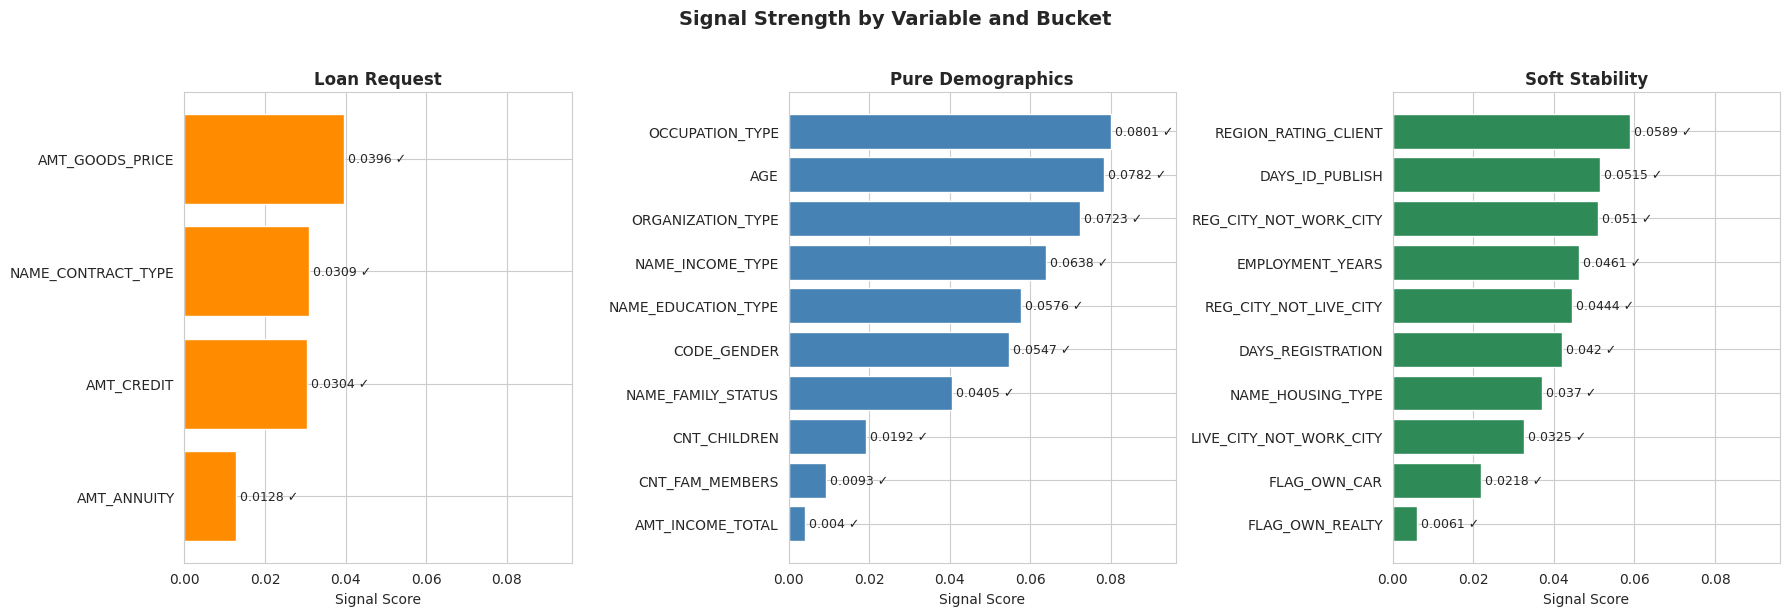

In [ ]:
import scipy.stats as stats
import numpy as np

# ============================================================
# STAGE 5 — UNIVARIATE SIGNAL EVALUATION
# ============================================================

results = []

# ------------------------------------------------------------
# FUNCTION 1 — For categorical variables
# Chi-Square test + Cramér's V
# ------------------------------------------------------------
def evaluate_categorical(col, bucket):
    contingency = pd.crosstab(app[col], app['TARGET'])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    n = len(app)
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k))
    results.append({
        'Variable': col,
        'Bucket': bucket,
        'Type': 'Categorical',
        'Test': 'Chi-Square + Cramér\'s V',
        'Signal Score': round(cramers_v, 4),
        'P-Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# ------------------------------------------------------------
# FUNCTION 2 — For continuous variables
# Point-Biserial Correlation
# ------------------------------------------------------------
def evaluate_continuous(col, bucket):
    corr, p_value = stats.pointbiserialr(app['TARGET'], app[col])
    results.append({
        'Variable': col,
        'Bucket': bucket,
        'Type': 'Continuous',
        'Test': 'Point-Biserial Correlation',
        'Signal Score': round(abs(corr), 4),
        'P-Value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# ============================================================
# BUCKET 1 — PURE DEMOGRAPHICS
# ============================================================
print("Evaluating Bucket 1 — Pure Demographics...")

# Categorical
for col in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
            'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    evaluate_categorical(col, 'Pure Demographics')

# Continuous
for col in ['AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL']:
    evaluate_continuous(col, 'Pure Demographics')

# ============================================================
# BUCKET 2 — LOAN REQUEST CHARACTERISTICS
# ============================================================
print("Evaluating Bucket 2 — Loan Request Characteristics...")

# Categorical
evaluate_categorical('NAME_CONTRACT_TYPE', 'Loan Request')

# Continuous
for col in ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    evaluate_continuous(col, 'Loan Request')

# ============================================================
# BUCKET 3 — SOFT STABILITY SIGNALS
# ============================================================
print("Evaluating Bucket 3 — Soft Stability Signals...")

# Categorical
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE']:
    evaluate_categorical(col, 'Soft Stability')

# Continuous
for col in ['EMPLOYMENT_YEARS', 'REGION_RATING_CLIENT', 'DAYS_REGISTRATION',
            'DAYS_ID_PUBLISH']:
    evaluate_continuous(col, 'Soft Stability')

# Binary flags — treat as categorical
for col in ['REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
            'LIVE_CITY_NOT_WORK_CITY']:
    evaluate_categorical(col, 'Soft Stability')

# ============================================================
# BUILD RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(results).sort_values('Signal Score', ascending=False)

print("\n=== SIGNAL STRENGTH RANKING — ALL VARIABLES ===\n")
print(results_df.to_string(index=False))

print("\n=== BUCKET 1 — PURE DEMOGRAPHICS ONLY ===\n")
demo_results = results_df[results_df['Bucket'] == 'Pure Demographics']
print(demo_results.to_string(index=False))

print("\n=== BUCKET 2 — LOAN REQUEST ONLY ===\n")
loan_results = results_df[results_df['Bucket'] == 'Loan Request']
print(loan_results.to_string(index=False))

print("\n=== BUCKET 3 — SOFT STABILITY ONLY ===\n")
stability_results = results_df[results_df['Bucket'] == 'Soft Stability']
print(stability_results.to_string(index=False))

# ============================================================
# VISUAL — SIGNAL STRENGTH BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bucket_colors = {
    'Pure Demographics': 'steelblue',
    'Loan Request': 'darkorange',
    'Soft Stability': 'seagreen'
}

for ax, (bucket, group) in zip(axes, results_df.groupby('Bucket')):
    group_sorted = group.sort_values('Signal Score', ascending=True)
    ax.barh(group_sorted['Variable'], group_sorted['Signal Score'],
            color=bucket_colors[bucket], edgecolor='white')
    ax.set_title(f'{bucket}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Signal Score')
    ax.set_xlim(0, results_df['Signal Score'].max() * 1.2)
    for i, (score, sig) in enumerate(zip(group_sorted['Signal Score'],
                                          group_sorted['Significant'])):
        marker = '✓' if sig == 'Yes' else '✗'
        ax.text(score + 0.001, i, f'{score} {marker}', va='center', fontsize=9)

plt.suptitle('Signal Strength by Variable and Bucket', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **5.1 Signal Evaluation Findings**

#### Key Context: How to Read the Signal Scores
Before interpreting the results, it is important to understand what the signal scores
mean. For categorical variables we used **Cramér's V** and for continuous variables
we used **Point-Biserial Correlation**. Both produce a score between 0 and 1:

- **0.00 — 0.10** → Weak association
- **0.10 — 0.30** → Moderate association
- **0.30 — 0.50** → Strong association
- **0.50+** → Very strong association

Every variable in this analysis scored **below 0.10**, meaning all associations
are in the weak range. However, every single variable was statistically significant
(p-value < 0.05), confirming these relationships are real and not random chance.
The question is therefore not whether demographics are related to NPL, they are,
but whether that relationship is strong enough to be useful for underwriting decisions.


---

#### Full Signal Ranking All Variables

| Rank | Variable | Bucket | Signal Score | Significant |
|---|---|---|---|---|
| 1 | OCCUPATION_TYPE | Pure Demographics | 0.0801 | Yes |
| 2 | AGE | Pure Demographics | 0.0782 | Yes |
| 3 | ORGANIZATION_TYPE | Pure Demographics | 0.0723 | Yes |
| 4 | NAME_INCOME_TYPE | Pure Demographics | 0.0638 | Yes |
| 5 | REGION_RATING_CLIENT | Soft Stability | 0.0589 | Yes |
| 6 | NAME_EDUCATION_TYPE | Pure Demographics | 0.0576 | Yes |
| 7 | CODE_GENDER | Pure Demographics | 0.0547 | Yes |
| 8 | DAYS_ID_PUBLISH | Soft Stability | 0.0515 | Yes |
| 9 | REG_CITY_NOT_WORK_CITY | Soft Stability | 0.0510 | Yes |
| 10 | EMPLOYMENT_YEARS | Soft Stability | 0.0461 | Yes |
| 11 | REG_CITY_NOT_LIVE_CITY | Soft Stability | 0.0444 | Yes |
| 12 | DAYS_REGISTRATION | Soft Stability | 0.0420 | Yes |
| 13 | NAME_FAMILY_STATUS | Pure Demographics | 0.0405 | Yes |
| 14 | AMT_GOODS_PRICE | Loan Request | 0.0396 | Yes |
| 15 | NAME_HOUSING_TYPE | Soft Stability | 0.0370 | Yes |
| 16 | LIVE_CITY_NOT_WORK_CITY | Soft Stability | 0.0325 | Yes |
| 17 | NAME_CONTRACT_TYPE | Loan Request | 0.0309 | Yes |
| 18 | AMT_CREDIT | Loan Request | 0.0304 | Yes |
| 19 | FLAG_OWN_CAR | Soft Stability | 0.0218 | Yes |
| 20 | CNT_CHILDREN | Pure Demographics | 0.0192 | Yes |
| 21 | AMT_ANNUITY | Loan Request | 0.0128 | Yes |
| 22 | CNT_FAM_MEMBERS | Pure Demographics | 0.0093 | Yes |
| 23 | FLAG_OWN_REALTY | Soft Stability | 0.0061 | Yes |
| 24 | AMT_INCOME_TOTAL | Pure Demographics | 0.0040 | Yes |

---

#### Bucket 1 Pure Demographics

| Variable | Signal Score |
|---|---|
| OCCUPATION_TYPE | 0.0801 |
| AGE | 0.0782 |
| ORGANIZATION_TYPE | 0.0723 |
| NAME_INCOME_TYPE | 0.0638 |
| NAME_EDUCATION_TYPE | 0.0576 |
| CODE_GENDER | 0.0547 |
| NAME_FAMILY_STATUS | 0.0405 |
| CNT_CHILDREN | 0.0192 |
| CNT_FAM_MEMBERS | 0.0093 |
| AMT_INCOME_TOTAL | 0.0040 |

The top performers in pure demographics are occupation type, age, organization type,
and income type, all scoring above 0.06. These are the variables doing most of the
work within this bucket.

The most striking finding is at the bottom, **income amount scores only 0.0040**,
which is effectively no signal. This is arguably the single most commonly used
traditional underwriting proxy, yet it is the weakest variable in the entire analysis.
A borrower's raw income figure tells us almost nothing about whether they will default.

---

#### Bucket 2 Loan Request Characteristics

| Variable | Signal Score |
|---|---|
| AMT_GOODS_PRICE | 0.0396 |
| NAME_CONTRACT_TYPE | 0.0309 |
| AMT_CREDIT | 0.0304 |
| AMT_ANNUITY | 0.0128 |

Loan request characteristics are collectively the weakest bucket. None of the four
variables break above 0.04. What a borrower is asking to borrow, the amount, the
type, the purpose, carries limited signal about whether they will repay it.

---

#### Bucket 3 Soft Stability Signals

| Variable | Signal Score |
|---|---|
| REGION_RATING_CLIENT | 0.0589 |
| DAYS_ID_PUBLISH | 0.0515 |
| REG_CITY_NOT_WORK_CITY | 0.0510 |
| EMPLOYMENT_YEARS | 0.0461 |
| REG_CITY_NOT_LIVE_CITY | 0.0444 |
| DAYS_REGISTRATION | 0.0420 |
| NAME_HOUSING_TYPE | 0.0370 |
| LIVE_CITY_NOT_WORK_CITY | 0.0325 |
| FLAG_OWN_CAR | 0.0218 |
| FLAG_OWN_REALTY | 0.0061 |

This is the most surprising result of Stage 5. Soft stability signals, variables
that many traditional lenders do not even formally collect, are **outperforming
several classic demographic proxies**. Region rating, address consistency flags,
and ID document age all score higher than education level, gender, and family status.

This suggests that life stability indicators carry more predictive information about
repayment behavior than static demographic characteristics, an important finding
that challenges the assumption that demographics are the primary lens for
creditworthiness assessment.

---

#### Summary

| Bucket | Strongest Variable | Weakest Variable | Score Range |
|---|---|---|---|
| Pure Demographics | OCCUPATION_TYPE (0.0801) | AMT_INCOME_TOTAL (0.0040) | 0.0040 — 0.0801 |
| Loan Request | AMT_GOODS_PRICE (0.0396) | AMT_ANNUITY (0.0128) | 0.0128 — 0.0396 |
| Soft Stability | REGION_RATING_CLIENT (0.0589) | FLAG_OWN_REALTY (0.0061) | 0.0061 — 0.0589 |

> **Stage 5 Headline:** All 24 variables show statistically significant but weak
> associations with NPL outcomes. The entire signal range spans only 0.0040 to 0.0801
> a narrow band that sits firmly in the weak association category. Traditional
> demographic proxies are real predictors of NPL but they are not strong ones.
> Notably, income amount, one of the most relied-upon traditional underwriting
> criteria carries almost no signal at all. And soft stability signals, which
> traditional lenders may not formally collect, outperform several classic demographic
> proxies. These findings set the baseline that Part 2 will challenge.

## **6 Borrower Risk Profiles**

#### What We Are Doing
Stage 5 told us how each demographic variable performs individually. But a lender
does not make a decision based on one variable in isolation, they look at the whole
borrower. Stage 6 builds on the Stage 5 findings by combining the strongest demographic
variables together to see how NPL rates shift across realistic borrower profiles.

This is not a statistical test. It is a structured observation, cross-tabulating
key demographic combinations to reveal which borrower profiles carry the highest and
lowest default risk within our population.

#### Why This Matters
Individual signal scores tell you which demographics are informative. Combined profiles
tell you what that actually looks like in real borrower terms. A fintech evaluating a
loan application does not see a Cramér's V score, they see a person with a specific
age, employment type, education level, and income category. This stage translates the
statistical findings from Stage 5 into that human-readable picture.

#### What We Are Combining
Based on the Stage 5 signal ranking, we focus on the top performing pure demographic
variables:

- **Occupation Type** strongest overall demographic signal (0.0801)
- **Age Group** strongest continuous demographic signal (0.0782)
- **Organization Type** strong categorical signal (0.0723)
- **Income Type** strong categorical signal (0.0638)
- **Education Level** moderate categorical signal (0.0576)
- **Gender** moderate categorical signal (0.0547)

We cross-tabulate these in meaningful combinations rather than all at once#, combining
all four simultaneously would produce too many small subgroups to be reliable. Instead
we build layered profiles that tell a coherent story about borrower risk.

=== PROFILE 1 — Age Group x Occupation Type ===

AGE_GROUP       OCCUPATION_TYPE  Borrower_Count  NPL_Rate Reliable
    25-35    Low-skill Laborers             711     19.69      Yes
      <25    Low-skill Laborers             173     18.50      Yes
    35-45    Low-skill Laborers             682     17.01      Yes
    25-35        Cleaning staff             622     16.88      Yes
    25-35        Security staff            1213     15.75      Yes
    25-35         Cooking staff            1536     15.36      Yes
      <25               Drivers             937     14.62      Yes
      <25              Laborers            3457     14.23      Yes
      <25         Cooking staff             302     13.91      Yes
      <25        Security staff             218     13.76      Yes
    45-55    Low-skill Laborers             429     13.75      Yes
    25-35  Waiters/barmen staff             468     13.68      Yes
      <25  Waiters/barmen staff             281     13.52      Yes
    25-35    

/tmp/ipython-input-211/3711152227.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile1 = app.groupby(['AGE_GROUP', 'OCCUPATION_TYPE']).agg(
/tmp/ipython-input-211/3711152227.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile2 = app.groupby(['AGE_GROUP', 'NAME_INCOME_TYPE']).agg(


AGE_GROUP     NAME_INCOME_TYPE  Borrower_Count  NPL_Rate Reliable
      <25              Working           10299     12.72      Yes
    25-35            Pensioner             278     12.59      Yes
    25-35              Working           47589     11.75      Yes
      <25 Commercial associate            4937     10.25      Yes
    35-45            Pensioner            1108     10.11      Yes
    35-45              Working           52213      9.13      Yes
    25-35 Commercial associate           21740      8.92      Yes
      <25        State servant            1028      8.85      Yes
    45-55              Working           38773      7.69      Yes
    25-35        State servant            6303      7.46      Yes
    35-45 Commercial associate           23097      7.01      Yes
    45-55 Commercial associate           17063      6.16      Yes
    45-55            Pensioner            8310      5.88      Yes
    55-65              Working            9592      5.85      Yes
    35-45 

/tmp/ipython-input-211/3711152227.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile4 = app.groupby(['AGE_GROUP', 'NAME_EDUCATION_TYPE',


--- TOP 10 HIGHEST RISK PROFILES ---
AGE_GROUP           NAME_EDUCATION_TYPE     NAME_INCOME_TYPE  Borrower_Count  NPL_Rate Reliable
      <25               Lower secondary              Working             108     20.37      Yes
    25-35               Lower secondary Commercial associate             151     17.88      Yes
    25-35               Lower secondary              Working             517     16.63      Yes
      <25 Secondary / secondary special              Working            6719     15.11      Yes
    25-35 Secondary / secondary special              Working           31721     13.69      Yes
    35-45               Lower secondary              Working             673     13.52      Yes
    25-35 Secondary / secondary special            Pensioner             212     13.21      Yes
      <25 Secondary / secondary special Commercial associate            2572     13.14      Yes
    55-65               Lower secondary              Working             130     12.31      Yes
   

/tmp/ipython-input-211/3711152227.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot1 = app.groupby(['AGE_GROUP', 'NAME_EDUCATION_TYPE'])['TARGET'].mean() * 100


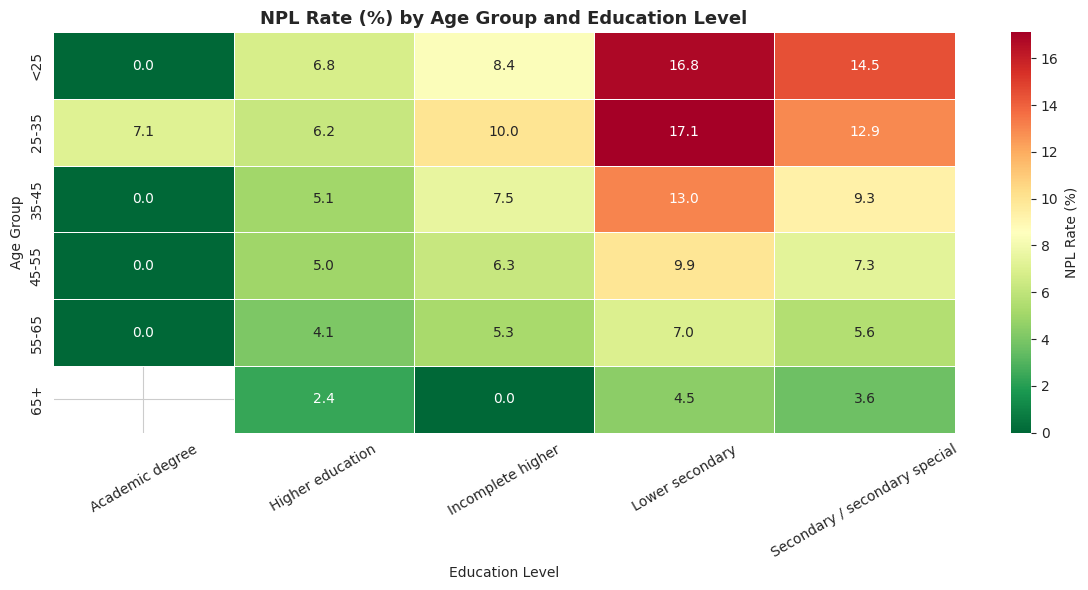

/tmp/ipython-input-211/3711152227.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot2 = app.groupby(['AGE_GROUP', 'NAME_INCOME_TYPE'])['TARGET'].mean() * 100


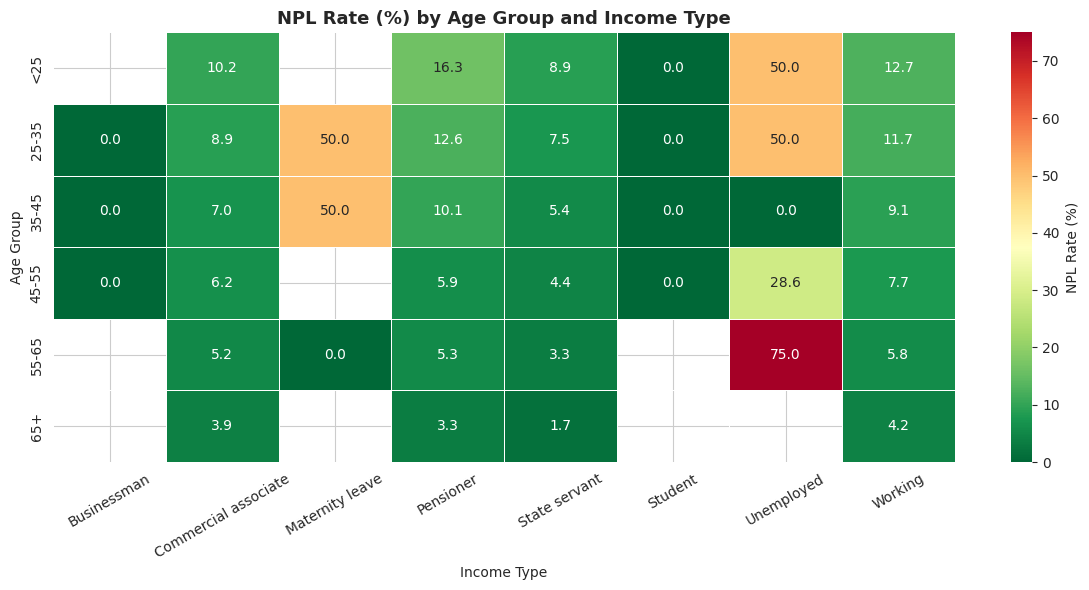

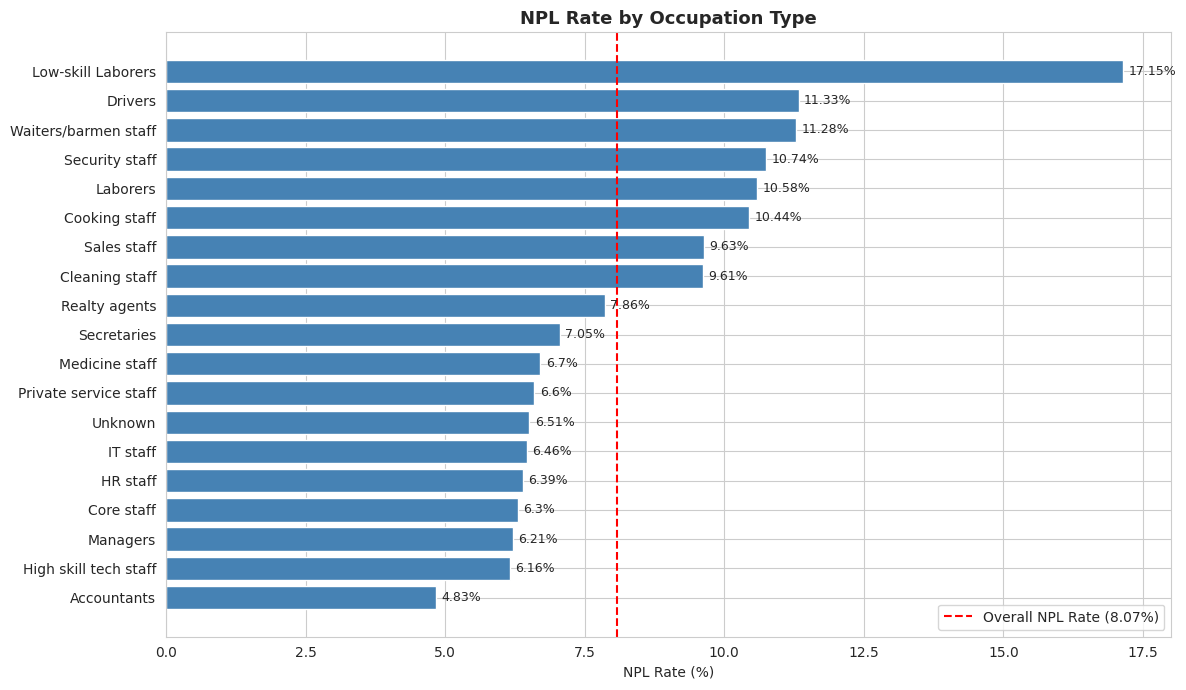

In [ ]:
# ============================================================
# STAGE 6 — BORROWER RISK PROFILES
# ============================================================

# Minimum group size to show — groups smaller than this are flagged as unreliable
MIN_GROUP_SIZE = 100

# ============================================================
# PROFILE 1 — Age Group x Occupation Type
# ============================================================
print("=== PROFILE 1 — Age Group x Occupation Type ===\n")
profile1 = app.groupby(['AGE_GROUP', 'OCCUPATION_TYPE']).agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
profile1['NPL_Rate'] = (profile1['NPL_Rate'] * 100).round(2)
profile1['Reliable'] = profile1['Borrower_Count'].apply(
    lambda x: 'Yes' if x >= MIN_GROUP_SIZE else 'No — small sample')
profile1_reliable = profile1[profile1['Reliable'] == 'Yes'].sort_values(
    'NPL_Rate', ascending=False)
print(profile1_reliable.to_string(index=False))

# ============================================================
# PROFILE 2 — Age Group x Income Type
# ============================================================
print("\n=== PROFILE 2 — Age Group x Income Type ===\n")
profile2 = app.groupby(['AGE_GROUP', 'NAME_INCOME_TYPE']).agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
profile2['NPL_Rate'] = (profile2['NPL_Rate'] * 100).round(2)
profile2['Reliable'] = profile2['Borrower_Count'].apply(
    lambda x: 'Yes' if x >= MIN_GROUP_SIZE else 'No — small sample')
profile2_reliable = profile2[profile2['Reliable'] == 'Yes'].sort_values(
    'NPL_Rate', ascending=False)
print(profile2_reliable.to_string(index=False))

# ============================================================
# PROFILE 3 — Gender x Occupation Type
# ============================================================
print("\n=== PROFILE 3 — Gender x Occupation Type ===\n")
profile3 = app.groupby(['CODE_GENDER', 'OCCUPATION_TYPE']).agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
profile3['NPL_Rate'] = (profile3['NPL_Rate'] * 100).round(2)
profile3['Reliable'] = profile3['Borrower_Count'].apply(
    lambda x: 'Yes' if x >= MIN_GROUP_SIZE else 'No — small sample')
profile3_reliable = profile3[profile3['Reliable'] == 'Yes'].sort_values(
    'NPL_Rate', ascending=False)
print(profile3_reliable.head(15).to_string(index=False))

# ============================================================
# PROFILE 4 — Age Group x Education x Income Type
# Three way full profile
# ============================================================
print("\n=== PROFILE 4 — Age Group x Education x Income Type ===\n")
profile4 = app.groupby(['AGE_GROUP', 'NAME_EDUCATION_TYPE',
                         'NAME_INCOME_TYPE']).agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
profile4['NPL_Rate'] = (profile4['NPL_Rate'] * 100).round(2)
profile4['Reliable'] = profile4['Borrower_Count'].apply(
    lambda x: 'Yes' if x >= MIN_GROUP_SIZE else 'No — small sample')
profile4_reliable = profile4[profile4['Reliable'] == 'Yes'].sort_values(
    'NPL_Rate', ascending=False)

print("--- TOP 10 HIGHEST RISK PROFILES ---")
print(profile4_reliable.head(10).to_string(index=False))
print("\n--- TOP 10 LOWEST RISK PROFILES ---")
print(profile4_reliable.tail(10).to_string(index=False))

# ============================================================
# PROFILE 5 — Occupation Type x Income Type
# The two strongest signals combined
# ============================================================
print("\n=== PROFILE 5 — Occupation Type x Income Type ===\n")
profile5 = app.groupby(['OCCUPATION_TYPE', 'NAME_INCOME_TYPE']).agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
profile5['NPL_Rate'] = (profile5['NPL_Rate'] * 100).round(2)
profile5['Reliable'] = profile5['Borrower_Count'].apply(
    lambda x: 'Yes' if x >= MIN_GROUP_SIZE else 'No — small sample')
profile5_reliable = profile5[profile5['Reliable'] == 'Yes'].sort_values(
    'NPL_Rate', ascending=False)

print("--- TOP 10 HIGHEST RISK PROFILES ---")
print(profile5_reliable.head(10).to_string(index=False))
print("\n--- TOP 10 LOWEST RISK PROFILES ---")
print(profile5_reliable.tail(10).to_string(index=False))

# ============================================================
# VISUAL 1 — Heatmap: Age Group x Education Level
# ============================================================
pivot1 = app.groupby(['AGE_GROUP', 'NAME_EDUCATION_TYPE'])['TARGET'].mean() * 100
pivot1 = pivot1.unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'NPL Rate (%)'})
plt.title('NPL Rate (%) by Age Group and Education Level',
          fontsize=13, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Age Group')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ============================================================
# VISUAL 2 — Heatmap: Age Group x Income Type
# ============================================================
pivot2 = app.groupby(['AGE_GROUP', 'NAME_INCOME_TYPE'])['TARGET'].mean() * 100
pivot2 = pivot2.unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'NPL Rate (%)'})
plt.title('NPL Rate (%) by Age Group and Income Type',
          fontsize=13, fontweight='bold')
plt.xlabel('Income Type')
plt.ylabel('Age Group')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ============================================================
# VISUAL 3 — Bar Chart: NPL Rate by Occupation Type
# ============================================================
occ_npl = app.groupby('OCCUPATION_TYPE').agg(
    Borrower_Count=('TARGET', 'count'),
    NPL_Rate=('TARGET', 'mean')
).reset_index()
occ_npl['NPL_Rate'] = (occ_npl['NPL_Rate'] * 100).round(2)
occ_npl = occ_npl[occ_npl['Borrower_Count'] >= MIN_GROUP_SIZE].sort_values(
    'NPL_Rate', ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(occ_npl['OCCUPATION_TYPE'], occ_npl['NPL_Rate'],
                color='steelblue', edgecolor='white')
plt.axvline(x=8.07, color='red', linestyle='--',
            linewidth=1.5, label='Overall NPL Rate (8.07%)')
plt.title('NPL Rate by Occupation Type', fontsize=13, fontweight='bold')
plt.xlabel('NPL Rate (%)')
plt.legend()
for bar, val in zip(bars, occ_npl['NPL_Rate']):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## **6.1 Borrower Risk Profile Findings**

#### What We Did
We combined the top performing demographic variables from Stage 5 to build borrower
risk profiles, cross-tabulating age, occupation type, income type, education level,
and gender to see how NPL rates shift across realistic borrower combinations.

A minimum group size of 100 borrowers was applied to ensure all reported profiles
are statistically reliable.

---

#### Profile 1, Age Group x Occupation Type
The combination of age and occupation produces the widest NPL spread of any profile
examined. Young low-skill laborers aged 25-35 default at **19.69%**, more than double
the overall rate of 8.07%. The pattern is consistent across the table:

- **Highest risk:** Young borrowers (under 35) in manual and service roles,
low-skill laborers, cleaning staff, security staff, cooking staff, and drivers
- **Lowest risk:** Older borrowers (45+) in professional roles, accountants,
managers, medical staff, and high-skill tech workers

The single lowest profile in this table is **IT staff aged 35-45 at 2.50%**,
nearly 8x lower than the highest risk profile.

---

#### Profile 2, Age Group x Income Type
Working borrowers under 25 default at **12.72%** and working borrowers aged 25-35
at **11.75%**. Pensioners and state servants consistently anchor the low-risk end
across all age groups regardless of age.

The safest profile here is **pensioners aged 65+ at 3.32%**, less than half the
overall NPL rate.

---

#### Profile 3, Gender x Occupation Type
Male low-skill laborers are the highest risk gender-occupation combination at
**17.49%**, followed closely by female low-skill laborers at **15.31%**. The gender
gap is present across most occupations, males default more consistently, but
occupation type is doing more of the predictive work than gender alone. Gender
amplifies the occupation signal rather than standing independently.

---

#### Profile 4 Age Group x Education x Income Type
This three-way combination produces the starkest contrast in the entire analysis:

| Profile | NPL Rate |
|---|---|
| Under 25 — Lower secondary — Working | 20.37% |
| 25-35 — Lower secondary — Commercial associate | 17.88% |
| 25-35 — Secondary — Working | 13.69% |
| 65+ — Higher education — Pensioner | 2.31% |
| 55-65 — Higher education — State servant | 3.28% |
| 35-45 — Higher education — State servant | 3.17% |

The gap between the **riskiest profile (20.37%) and the safest profile (2.31%)
is nearly 10x**. This is the widest separation demographics can produce in this
dataset when combined.

---

#### Profile 5 Occupation Type x Income Type
Low-skill laborers in regular employment default at **17.33%** while managers and
IT staff in state servant or commercial associate roles sit around **3.87-3.92%**.
This confirms that occupation type combined with employment category is the most
powerful two-variable demographic combination available.

---

#### Key Findings from Stage 6

**1. Combining variables does produce meaningful risk differentiation.**
The gap between the riskiest and safest demographic profile reaches nearly 10x —
from 20.37% down to 2.31%. That is a real and directionally useful signal.

**2. Age and occupation are doing most of the work.**
Across all five profiles, the dominant pattern is consistent, young people in
manual and low-skill roles are high risk, older people in professional or pensioner
categories are low risk. Adding education and income type sharpens the picture
slightly but does not change the story.

**3. Even the worst demographic profile still has an 80% repayment rate.**
This is the most important finding for our research narrative. Even in the riskiest
demographic combination, young, low education, working, 4 out of 5 borrowers
still repaid. Demographics are separating groups directionally but not precisely
enough to make reliable individual lending decisions. A lender relying purely on
demographic profiles would reject many borrowers who would have repaid, which is
exactly the financial inclusion problem this project is built around.

> **Stage 6 Headline:** Demographic profiles can separate high-risk and low-risk
> borrower groups directionally, with up to a 10x NPL rate difference between
> extremes. But even the highest-risk demographic profile carries an 80% repayment
> rate, meaning demographics alone are too blunt a tool for individual credit
> decisions. This sets the ceiling for what traditional proxies can achieve and
> makes the case for Part 2, whether behavioral signals can draw a sharper line.

## **7 Baseline Verdict**

#### The Question We Set Out to Answer
How well do traditional demographic proxies predict NPL outcomes for thin-file and
underbanked borrowers, the population that traditional lenders struggle to serve?

This is the question Part 1 was built to answer. Everything from data cleaning to
feature definition to signal testing to profile building was in service of producing
an honest, evidence-backed answer to this question. Here is that answer.

---

#### What the Individual Variable Testing Showed (Stage 5)

Every single demographic variable tested showed a statistically significant
relationship with NPL outcomes, meaning none of the patterns we observed were
random. But statistical significance is not the same as practical usefulness.

Every variable scored below 0.10 on the signal strength scale, firmly in the
weak association range. The full signal spectrum across all 24 variables spanned
only **0.0040 to 0.0801**, an extremely narrow band that tells us demographics
are real but weak predictors.

The strongest individual signals were:

| Variable | Signal Score |
|---|---|
| Occupation Type | 0.0801 |
| Age | 0.0782 |
| Organization Type | 0.0723 |
| Income Type | 0.0638 |
| Education Level | 0.0576 |
| Gender | 0.0547 |

The weakest, and most surprising, finding was income amount, scoring just
**0.0040**. This is arguably the most commonly used traditional underwriting
proxy, yet it carries almost no predictive signal on its own. A borrower's raw
income figure tells us very little about whether they will default.

Also notable is that soft stability signals, variables many traditional lenders
do not formally collect, outperformed several classic demographic proxies. Region
rating (0.0589), address consistency flags (0.0510), and ID document age (0.0515)
all scored higher than education level, gender, and family status. This suggests
that life stability indicators carry more information about repayment behavior than
static demographic characteristics.

---

#### What the Combined Profiles Showed (Stage 6)

When demographic variables are combined, the risk differentiation improves. The
gap between the riskiest and safest demographic profile reaches nearly **10x**,
from a high of **20.37%** for young borrowers with lower secondary education in
regular employment, down to **2.31%** for older pensioners with higher education.

The dominant pattern across all profiles was consistent, young borrowers in
manual and low-skill occupations are high risk, older borrowers in professional
or pensioner categories are low risk. Age and occupation type drove most of this
separation. Adding education and income type sharpened the picture slightly but
did not fundamentally change the story.

However the most important number from Stage 6 is this, **even in the riskiest
demographic profile, 80% of borrowers still repaid their loan.** Demographics
can point a lender in a direction but they cannot draw a precise enough line to
make reliable individual credit decisions. For every high-risk demographic profile,
the majority of borrowers within it would have repaid, and a lender relying purely
on demographics would have rejected them anyway.

---

#### The Baseline Verdict

> Traditional demographic proxies are statistically real but practically weak
> predictors of NPL outcomes for thin-file borrowers.

The evidence supports three specific conclusions:

**1. Demographics carry signal but not enough signal.**
All variables are significant but all are weak. The strongest single variable,
occupation type, scores just 0.0801. Even combining the best variables together
only pushes the riskiest profiles to around 20% NPL, meaning demographics cannot
reliably separate borrowers who will default from those who will not at the
individual level.

**2. The most relied-upon traditional proxy, income amount, is the weakest.**
With a signal score of 0.0040, raw income carries almost no predictive information
about repayment behavior. This is a direct challenge to the foundation of
traditional demographic underwriting.

**3. Demographics are a blunt tool, useful for group-level patterns,
insufficient for individual decisions.**
A lender using only demographic proxies would reject many borrowers who would
have repaid, because even the highest-risk demographic groups contain a majority
of good borrowers. This is the financial inclusion cost of demographic-based
underwriting.

---

#### What This Means for Part 2

This baseline is now the reference point. Traditional demographic proxies, even
at their best, produce weak individual-level signal and leave most good borrowers
inside high-risk demographic groups unserved.

Part 2 will ask whether behavioral payment signals from repayment history can draw
a sharper line. If behavioral signals produce stronger associations with NPL outcomes
than the 0.0040 to 0.0801 range established here, and if they can better separate
defaulters from non-defaulters at the individual level, then we have evidence that
alternative data is not just different from demographic proxies but meaningfully
better than them.

That is the comparison Part 2 is built to make.